# Forecasting AIFUL's Business Performance Using Public IR Data

**Business question:** *Where will AIFUL's core consumer-loan business be in 12 months — loan balance and new-customer acquisition — and what should management do about it?*

**Data:** AIFUL's official *Monthly Data* reports (Muninova Holdings IR site), April 2012 – August 2026, 173 months.
Only published numbers are used — nothing is estimated or invented.

**Notebook map**
1. Load & validate the data
2. Exploratory analysis — trends, seasonality, events
3. Forecasting — seasonal-naive baseline vs SARIMA vs Prophet, 9-origin backtest, 12-month forecast
4. Management summary — headline chart and the numbers quoted in the report

**Headline result:** SARIMA is the most accurate model in the backtest (1.2% error on the loan balance, 12 months ahead). It forecasts the balance at **~¥683bn in Mar-2027, ~¥12bn below management's ¥695.6bn plan**, because the contract rate has fallen from ~45% to ~28%.

## 1. Load & validate the data

The raw PDFs are parsed by `src/build_dataset.py` (see the comments in that file).
It runs five checks before saving — including matching our computed year-on-year growth
against the YoY % AIFUL prints in every PDF. If any check fails, it stops.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
from build_dataset import build, validate

df = build()          # parse the 15 PDFs -> one monthly table
validate(df)          # stop if anything looks wrong
df.to_csv(ROOT / "data" / "processed" / "aiful_monthly.csv")

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
df.tail()

Found 15 PDF files


YoY check: 161 months match AIFUL's published YoY (max gap 0.05pp)
All checks passed: 173 months, Apr-2012 to Aug-2026


,total_receivables_jpy_mn,loans_outstanding_jpy_mn,unsecured_loans_jpy_mn,secured_loans_jpy_mn,small_business_loans_jpy_mn,guarantee_balance_jpy_mn,customer_accounts_k,unsecured_accounts_k,contract_rate_pct,applications,new_accounts,delinquent_loan_ratio_pct,interest_refund_claims,source_file
month,,,,,,,,,,,,,,
2026-04-01,1055073,675212,656628,1023,17559,379735,1417,1402,28.3,83281,23602,0.574,60,aiful_monthly_FY2026.pdf
2026-05-01,1071110,683053,664309,1007,17736,387931,1432,1417,27.8,92607,25741,0.759,60,aiful_monthly_FY2026.pdf
2026-06-01,1073418,676108,657580,977,17550,397189,1415,1400,29.4,78052,22974,0.528,70,aiful_monthly_FY2026.pdf
2026-07-01,1085101,676416,657907,954,17554,408564,1417,1403,28.7,73882,21180,0.756,70,aiful_monthly_FY2026.pdf
2026-08-01,1103205,682512,663982,938,17591,420574,1430,1415,28.2,80478,22657,0.654,50,aiful_monthly_FY2026.pdf


In [2]:
# Chart style used throughout (colour-blind-safe palette, light grid)
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#898781"
plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.edgecolor": GREY, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titlesize": 12, "axes.titleweight": "bold", "lines.linewidth": 2,
})

def shade_events(ax, label=True):
    # Shade the two macro shocks in the sample window (sources in section 2.6).
    ax.axvspan(pd.Timestamp("2020-04-01"), pd.Timestamp("2021-09-30"), color=GREY, alpha=0.12, lw=0)
    ax.axvspan(pd.Timestamp("2024-03-01"), df.index.max(), color=ORANGE, alpha=0.08, lw=0)
    if label:
        top = ax.get_ylim()[1]
        ax.text(pd.Timestamp("2020-05-01"), top, "COVID emergency\nperiods", va="top", fontsize=8, color="#52514e")
        ax.text(pd.Timestamp("2024-04-01"), top, "BoJ rate\nhikes", va="top", fontsize=8, color="#52514e")

def save(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight", dpi=150)

**Column guide** (Japanese label → our name). `¥mn` = million yen, `_k` = thousands.

| Our column | PDF label | Meaning |
|---|---|---|
| `unsecured_loans_jpy_mn` | 無担保ローン / 個人向け無担保 | Unsecured personal loan balance — AIFUL's core product |
| `loans_outstanding_jpy_mn` | 営業貸付金残高 | All loans (unsecured + secured + small business) |
| `unsecured_accounts_k` | 口座数（残高あり） 無担保 | Customers with an outstanding unsecured loan |
| `applications` | 申込件数 | New loan applications in the month |
| `new_accounts` | 新規獲得件数 | Applications that became customers |
| `contract_rate_pct` | 無担保新規成約率 | new_accounts ÷ applications |
| `delinquent_loan_ratio_pct` | 無担保解約発生率 ("Delinquent Loan Ratio") | Credit-risk indicator, former-AIFUL book |

## 2. Exploratory analysis

### 2.1 The big picture: the loan book

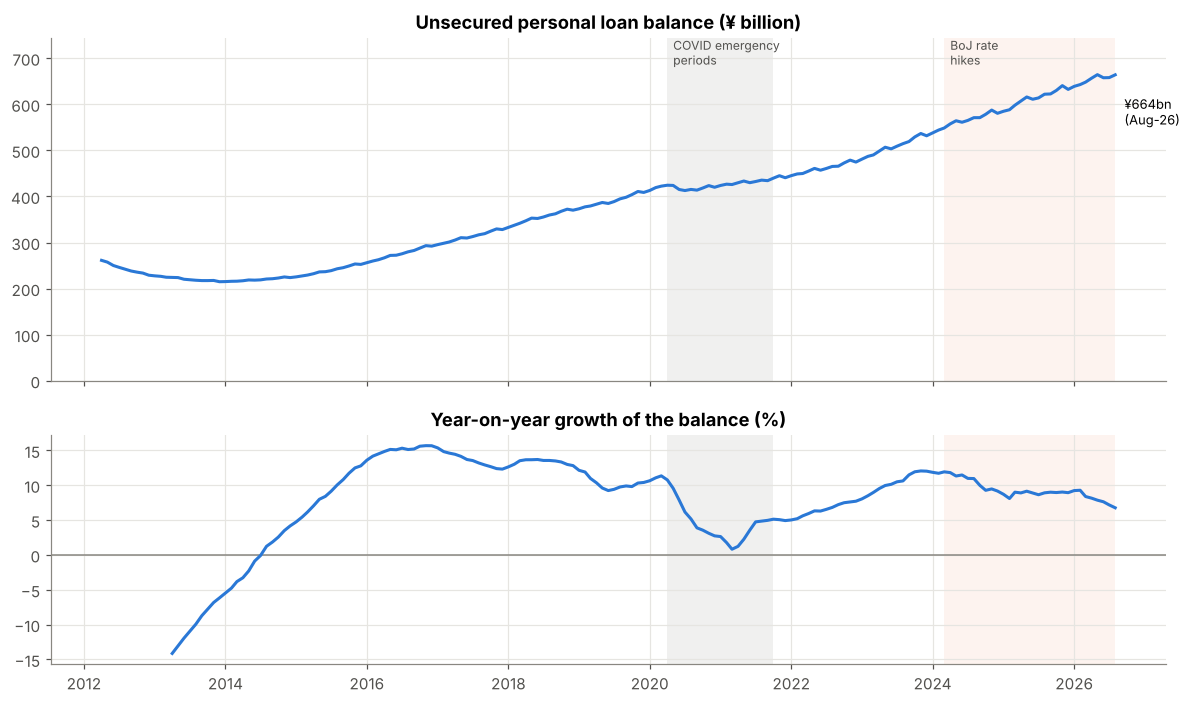

,unsecured_balance_end_¥bn,applications,new_accounts,contract_rate_%,months
fiscal_year (Apr–Mar),,,,,
2012,224.7,230360,87515,37.8,12
2013,216.1,260289,117008,45.0,12
2014,229.4,340351,153135,45.0,12
2015,262.7,388541,180666,46.5,12
2016,301.1,403361,182604,45.2,12
2017,341.8,433016,197565,45.6,12
2018,379.3,440479,199353,45.2,12
2019,422.4,471714,206155,43.7,12
2020,425.8,401337,161111,40.2,12


In [3]:
loans = df["unsecured_loans_jpy_mn"].astype(float) / 1000          # ¥ billion
yoy = df["unsecured_loans_jpy_mn"].astype(float).pct_change(12) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
ax1.plot(loans.index, loans, color=BLUE)
ax1.set_title("Unsecured personal loan balance (¥ billion)")
ax1.set_ylim(0, loans.max() * 1.12)
shade_events(ax1)
ax1.annotate(f"¥{loans.iloc[-1]:.0f}bn\n(Aug-26)", (loans.index[-1], loans.iloc[-1]),
             xytext=(6, -14), textcoords="offset points", fontsize=8.5, va="top")

ax2.axhline(0, color=GREY, lw=1)
ax2.plot(yoy.index, yoy, color=BLUE)
ax2.set_title("Year-on-year growth of the balance (%)")
shade_events(ax2, label=False)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout(); save(fig, "01_loan_balance_trend.png"); plt.show()

fy = df.index.year.where(df.index.month >= 4, df.index.year - 1)
summary = pd.DataFrame({
    "unsecured_balance_end_¥bn": (df["unsecured_loans_jpy_mn"].astype(float) / 1000).groupby(fy).last().round(1),
    "applications": df["applications"].groupby(fy).sum(),
    "new_accounts": df["new_accounts"].groupby(fy).sum(),
    "contract_rate_%": df["contract_rate_pct"].groupby(fy).mean().round(1),
    "months": df["applications"].groupby(fy).count(),
})
summary.index.name = "fiscal_year (Apr–Mar)"
summary

**What this shows**
- **2012–2014: shrinking, then stabilising.** The balance falls to ~¥216bn in FY2013. This is the tail of Japan's 2010 lending reforms (interest-rate cap at 20%, borrowing capped at 1/3 of annual income) and AIFUL's own restructuring.
- **FY2015–FY2019: steady double-digit growth** (11–15% a year).
- **FY2020: growth stops (+0.8%).** COVID: applications collapsed in spring 2020 and customers paid down debt.
- **FY2021–FY2023: recovery** back to ~12% growth.
- **FY2024 → today: slowing.** Growth has fallen from ~12% to **6.8% YoY in Aug-2026**. The cause is in the funnel (next chart), not in the existing book.

### 2.2 The customer-acquisition funnel

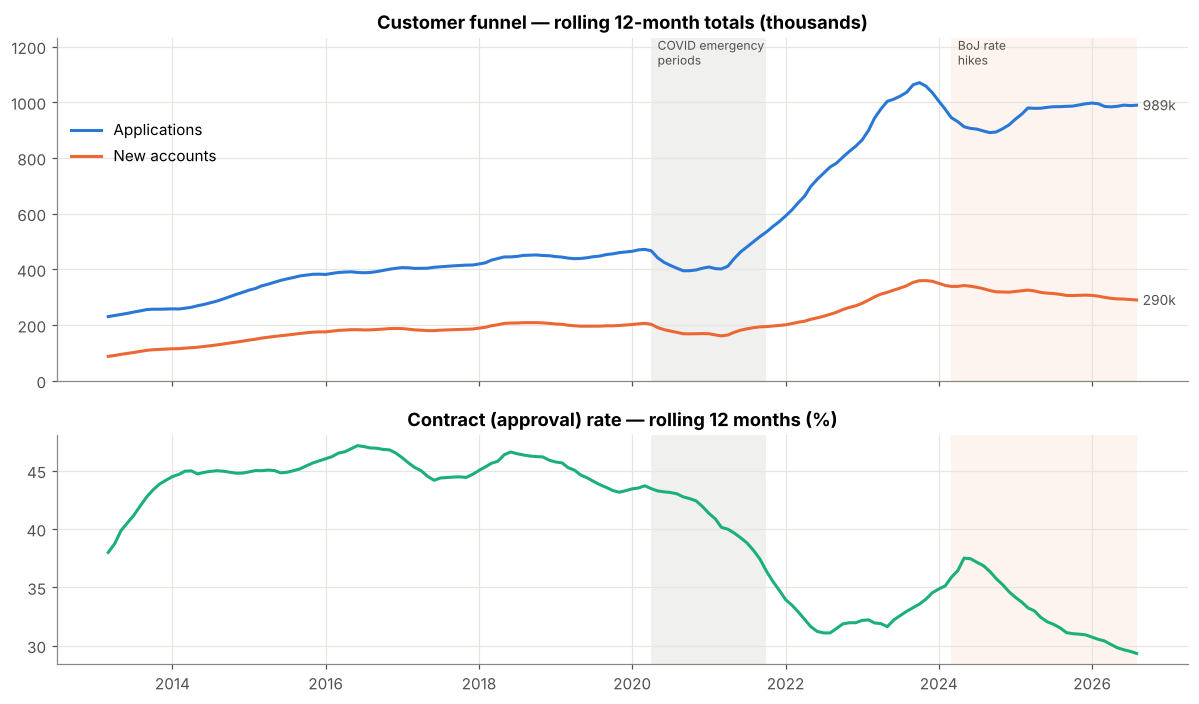

In [4]:
apps_12m = df["applications"].astype(float).rolling(12).sum() / 1000
new_12m = df["new_accounts"].astype(float).rolling(12).sum() / 1000
cr_12m = (df["new_accounts"].astype(float).rolling(12).sum() / df["applications"].astype(float).rolling(12).sum()) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
ax1.plot(apps_12m.index, apps_12m, color=BLUE, label="Applications")
ax1.plot(new_12m.index, new_12m, color=ORANGE, label="New accounts")
ax1.set_title("Customer funnel — rolling 12-month totals (thousands)")
ax1.set_ylim(0, apps_12m.max() * 1.15)
shade_events(ax1)
for s, c in [(apps_12m, BLUE), (new_12m, ORANGE)]:
    ax1.annotate(f"{s.iloc[-1]:.0f}k", (s.index[-1], s.iloc[-1]), xytext=(4, 0), textcoords="offset points", color="#52514e", fontsize=9, va="center")
ax1.legend(loc="upper left", frameon=False, bbox_to_anchor=(0, 0.8))

ax2.plot(cr_12m.index, cr_12m, color=AQUA)
ax2.set_title("Contract (approval) rate — rolling 12 months (%)")
shade_events(ax2, label=False)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout(); save(fig, "02_customer_funnel.png"); plt.show()

**What this shows**
- **Applications more than doubled after COVID** (~470k a year in FY2019 → ~980k in FY2024–25).
- **But the contract rate fell in two waves:** from ~45% before COVID to ~31% in 2022, back up to ~37% in 2024, then down again to ~29% (12-month basis; 28.2% in Aug-2026). So new accounts grew far less than applications, and since FY2023 they have been **falling** (339k → 299k in FY2025; −7.4% YoY so far in FY2026).
- Management confirms this is the problem. In the Q1 FY2027/3 briefing they said *"the issue lies in the contract rate"*, cost per acquisition is ~¥58,000 against ~¥40–50k planned, and they are reviewing the credit-scoring model.
- **Interview line:** loan growth is a funnel — `new accounts = applications × contract rate`. AIFUL still wins applications (top of the industry, by their own account). It converts fewer of them.

### 2.3 Seasonality

**Seasonality** means a pattern that repeats every calendar year. To measure it, divide each month by a 12-month centred moving average (the trend). A value of 1.10 means "10% above trend in that month".

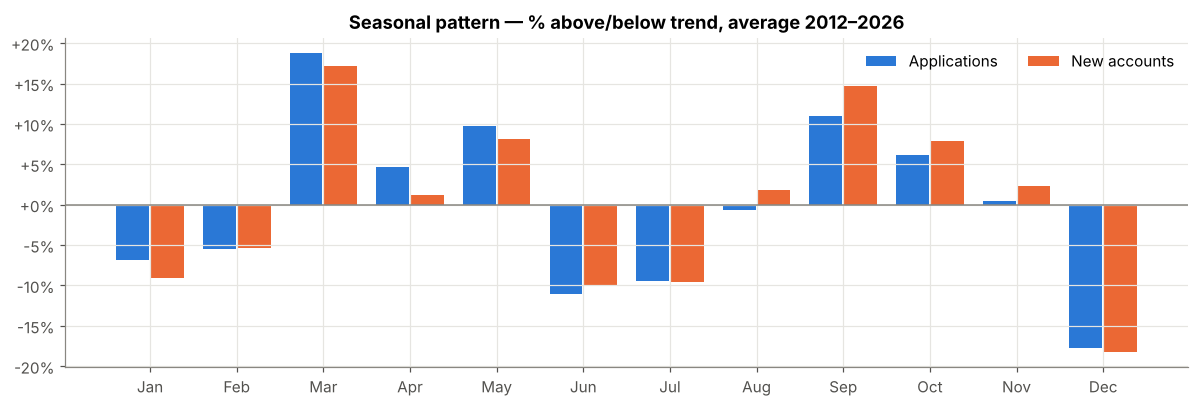

,Applications,New accounts
Jan,0.932,0.909
Feb,0.945,0.947
Mar,1.188,1.172
Apr,1.046,1.011
May,1.097,1.082
Jun,0.889,0.899
Jul,0.906,0.905
Aug,0.994,1.019
Sep,1.110,1.148
Oct,1.062,1.079


In [5]:
def seasonal_index(series):
    s = series.astype(float)
    trend = s.rolling(12, center=True).mean().rolling(2).mean().shift(-1)   # centred 2x12 moving average
    ratio = s / trend
    return ratio.groupby(ratio.index.month).mean()

season = pd.DataFrame({"Applications": seasonal_index(df["applications"]),
                       "New accounts": seasonal_index(df["new_accounts"])})
season.index = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(12); w = 0.38
ax.bar(x - w/2 - 0.01, season["Applications"] - 1, w, color=BLUE, label="Applications")
ax.bar(x + w/2 + 0.01, season["New accounts"] - 1, w, color=ORANGE, label="New accounts")
ax.axhline(0, color=GREY, lw=1)
ax.set_xticks(x, season.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_title("Seasonal pattern — % above/below trend, average 2012–2026")
ax.legend(frameon=False, ncol=2, loc="upper right")
fig.tight_layout(); save(fig, "03_seasonality_funnel.png"); plt.show()
season.round(3)

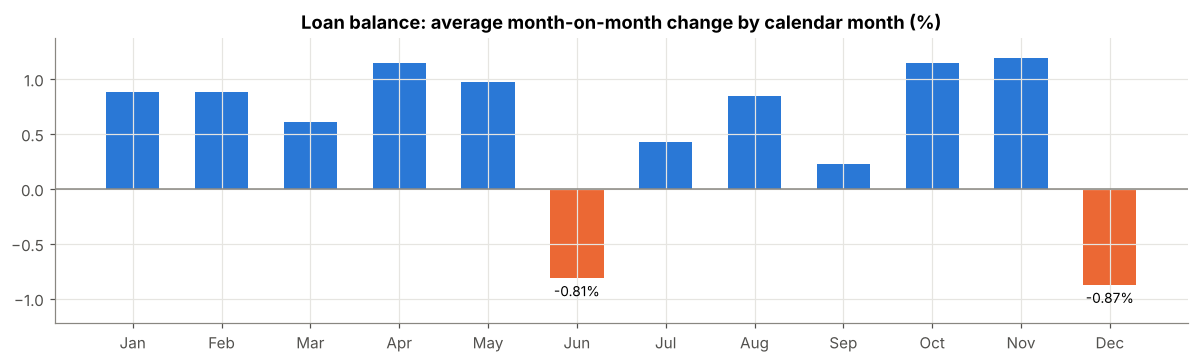

In [6]:
# Month-on-month change of the loan balance, averaged by calendar month
mom = df["unsecured_loans_jpy_mn"].astype(float).pct_change() * 100
mom_by_month = mom.groupby(mom.index.month).mean()
mom_by_month.index = season.index

fig, ax = plt.subplots(figsize=(11, 3.4))
colors = [ORANGE if v < 0 else BLUE for v in mom_by_month]
ax.bar(season.index, mom_by_month, color=colors, width=0.6)
ax.axhline(0, color=GREY, lw=1)
ax.set_ylim(mom_by_month.min() * 1.4, mom_by_month.max() * 1.15)
ax.set_title("Loan balance: average month-on-month change by calendar month (%)")
for i, v in enumerate(mom_by_month):
    if v < 0:
        ax.annotate(f"{v:.2f}%", (i, v), xytext=(0, -12), textcoords="offset points", ha="center", fontsize=9)
fig.tight_layout(); save(fig, "04_seasonality_balance.png"); plt.show()

**What this shows**
- **March, May, September, October:** applications and new accounts run 6–19% above trend. Japan's fiscal year starts in April, so these are moves, new jobs and half-year ends.
- **June and December:** the loan balance **shrinks** (−0.8% and −0.9% on average) while every other month grows. These are Japan's summer and winter **bonus months**, when customers repay. Applications and new accounts are also weakest in December.
- Why it matters for Step 4: the seasonality is real and regular, so the models need a 12-month seasonal component (that is the "S" in SARIMA).
- The STL chart below separates trend, seasonality and noise. The huge negative residual in spring 2020 is COVID: a one-off shock, not a pattern, which is why we use a *robust* fit that down-weights outliers.

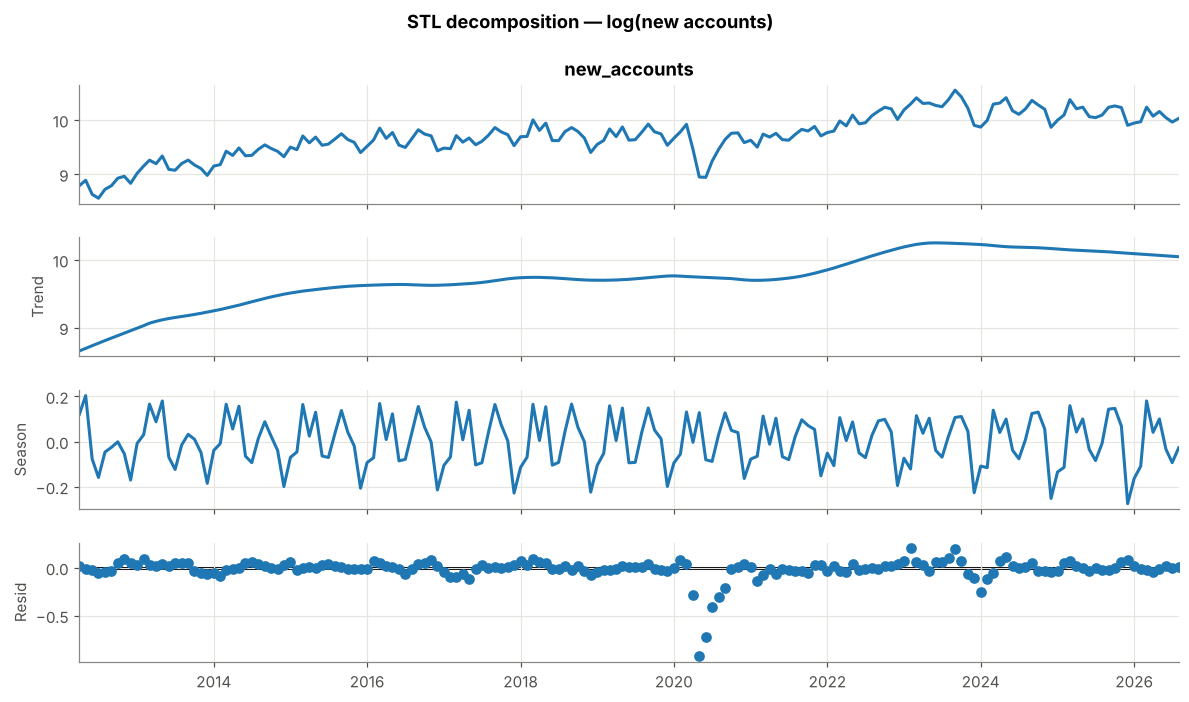

Seasonal strength (0 = none, 1 = pure seasonality): 0.48


In [7]:
from statsmodels.tsa.seasonal import STL

# STL splits a series into trend + seasonal + remainder. log() makes the seasonal part a % effect.
stl = STL(np.log(df["new_accounts"].astype(float)), period=12, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(11, 6.5)
fig.suptitle("STL decomposition — log(new accounts)", y=1.01, fontweight="bold")
save(fig, "05_stl_new_accounts.png"); plt.show()

strength = max(0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
print(f"Seasonal strength (0 = none, 1 = pure seasonality): {strength:.2f}")

### 2.4 Credit quality and legacy issues

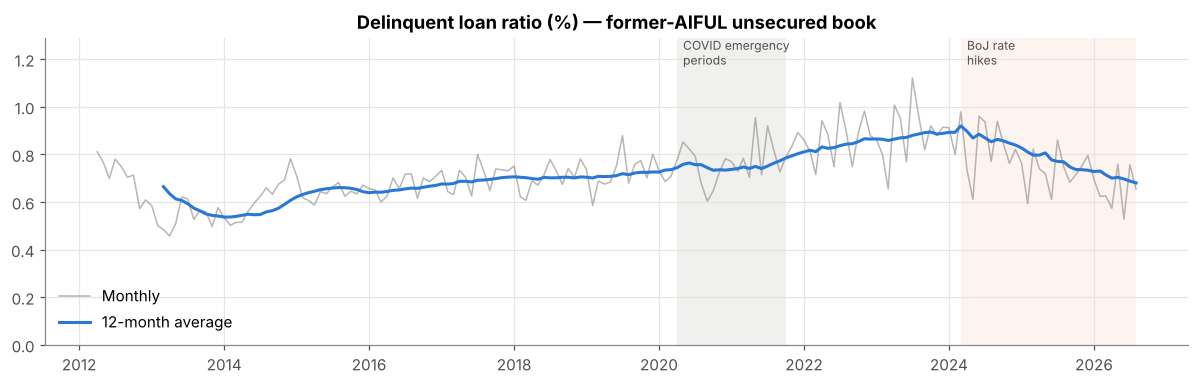

Interest-refund claims per month: 3,600 (FY2016 avg) -> 62 (FY2026 YTD avg)


In [8]:
dlq = df["delinquent_loan_ratio_pct"].astype(float)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(dlq.index, dlq, color=GREY, lw=1, alpha=0.6, label="Monthly")
ax.plot(dlq.index, dlq.rolling(12).mean(), color=BLUE, label="12-month average")
ax.set_ylim(0, dlq.max() * 1.15)
shade_events(ax)
ax.set_title("Delinquent loan ratio (%) — former-AIFUL unsecured book")
ax.legend(frameon=False, loc="lower left")
fig.tight_layout(); save(fig, "06_credit_quality.png"); plt.show()

claims = df["interest_refund_claims"].dropna().astype(float)
print("Interest-refund claims per month: "
      f"{claims.iloc[:12].mean():,.0f} (FY2016 avg) -> {claims.iloc[-5:].mean():,.0f} (FY2026 YTD avg)")

**What this shows**
- Credit quality worsened as the book grew fast after COVID (12-month average peaked at ~0.92% in FY2023). It has since improved to ~0.7%. That fits a more cautious approval policy, and the falling contract rate is the price of it. *This link is our interpretation; AIFUL has not said it.*
- The old overcharged-interest refund problem (過払い金) has faded, down ~98% from FY2016. It is no longer a material risk.

### 2.5 Data-quality check: the customer-accounts footnote

Footnote *1 in the PDFs says some former-LIFE accounts are included only in quarter-end months (Mar/Jun/Sep/Dec). If that mattered, accounts would jump every quarter-end and fall back afterwards.

In [9]:
acc_change = df["unsecured_accounts_k"].astype(float).diff()
by_month = acc_change.groupby(acc_change.index.month).mean().round(1)
by_month.index = season.index
print("Average month-on-month change in unsecured accounts ('000):")
print(by_month.to_string())

Average month-on-month change in unsecured accounts ('000):
Jan     4.8
Feb     5.9
Mar     7.0
Apr     7.0
May     9.3
Jun    -6.8
Jul     0.9
Aug     7.9
Sep     3.9
Oct     6.8
Nov    10.0
Dec    -8.2


**Result:** no quarter-end jump. March and September look like normal months, and the only negative months are **June and December**, which are the bonus-repayment effect again. The footnote's effect is too small to see, so the series is safe to use.

**Another flag:** the credit-guarantee balance jumps from ¥58bn to ¥87bn in June 2013 — a one-off step that AIFUL's company history doesn't explain. It doesn't affect our forecast targets, so we note it and move on.

### 2.6 Event timeline (with sources)

| Date | Event | Visible in data? | Source |
|---|---|---|---|
| Dec 2009 | AIFUL enters out-of-court restructuring (ADR) | Before sample; explains the shrinking 2012–13 book | [Taipei Times](https://www.taipeitimes.com/News/biz/archives/2009/12/25/2003461744) |
| Jun 2010 | Money Lending Business Act fully in force: 20% interest cap, total-volume cap (1/3 of income) | Before sample; permanently lower growth ceiling | [FSA Q&A](https://www.fsa.go.jp/policy/kashikin/qa.html) |
| Jul 2011 | LIFE and City's merged into AIFUL | Why the clean series starts in Apr-2012 | [Muninova history](https://www.muninova.co.jp/en/about/history.html) |
| Apr 2020 – Sep 2021 | COVID states of emergency (first one 7 Apr 2020, nationwide 16 Apr) | Applications −50% in May–Jun 2020; FY2020 growth +0.8% | [nippon.com](https://www.nippon.com/en/news/yjj2020041600764/) |
| Mar 2024 | BoJ ends negative rates — first hike in 17 years | Start of rising funding costs | [CNBC](https://www.cnbc.com/2024/03/19/bank-of-japan-boj-march-2024-policy-decision-mpm-meeting.html) |
| Jan 2025 | BoJ raises rate to 0.5% | | [Business Standard](https://www.business-standard.com/world-news/bank-of-japan-interest-rate-hike-17-years-highest-since-2008-25-basis-points-0-5-125012400326_1.html) |
| Dec 2025 | BoJ raises to 0.75% | | [Trading Economics](https://tradingeconomics.com/japan/interest-rate/news/511284) |
| Apr 2026 | Muninova Holdings set up as the group holding company | No break in AIFUL's monthly series | [Muninova history](https://www.muninova.co.jp/en/about/history.html) |
| Jun 2026 | BoJ raises to 1.0% | | [BoJ statement](https://www.boj.or.jp/en/mopo/mpmdeci/mpr_2026/k260616a.pdf) |
| Sep 2026 | BoJ raises to 1.25% (after our data ends) | Forecast risk | [UPI](https://www.upi.com/Top_News/World-News/2026/09/18/japan-policy-rate-raised-central-bank-weak-yen/6681789772736/) |
| FY2025–26 | Management flags the falling contract rate, CPA ~¥58k vs ¥40–50k plan, credit-scoring review | Contract rate ~28%, new accounts falling | [Q1 FY27/3 briefing Q&A](https://www.muninova.co.jp/ir/pdf/SCRTE202606.pdf), [FY26/3 Q&A](https://www.muninova.co.jp/ir/pdf/SCRTE202603.pdf) |

Why rate hikes matter for a consumer lender: AIFUL's **lending** rate is capped by law at 15–20%, but its **funding** rate floats with the market. Every BoJ hike squeezes the margin. AIFUL's financial expenses rose 31% in FY2026/3 and 36% YoY in Q1 FY2027/3 (same Q&A documents).

### 2.7 EDA takeaways → what we forecast next

1. **Unsecured loan balance:** a smooth upward trend, a small seasonal dip in June and December, and slowing growth. A good fit for SARIMA, which handles trend plus seasonality.
2. **New accounts:** strongly seasonal and noisy, with a level that has shifted since 2023 because of the contract rate. The hardest target, and the one most useful to management.
3. **Applications:** demand at the top of the funnel. Forecasting it separately lets us show management whether a shortfall comes from *demand* or from *conversion*.
4. **Structural breaks** (COVID 2020, the post-2021 application surge) mean older history is less relevant. In Step 4 we test the models on the most recent period only.

## 3. Forecasting

### 3.1 Set-up decisions (and why)

| Decision | Choice | Why |
|---|---|---|
| Targets | Unsecured loan balance, applications, new accounts | Balance = the business size. Applications × contract rate = new accounts, so forecasting both separates *demand* from *conversion*. |
| Horizon | 12 months (Sep-2026 → Aug-2027) | Matches an annual planning cycle. |
| Transform | Model `log(y)`, convert back with `exp()` | Seasonal swings are roughly a % of the level (March is ~+19% whether volumes are 30k or 90k). Logs turn % effects into additive ones, and forecasts can never go negative. |
| COVID | A 0/1 dummy for Apr–Sep 2020 in both models | Tells the model "these months were a one-off shock", so it doesn't learn them as a pattern. Set to 0 in the future. |
| Baseline | Seasonal naive: *next March = last March* | A model has to beat this to be worth using. |

In [10]:
import itertools, logging, warnings

# statsmodels/prophet print many harmless optimiser messages; hide them so the notebook stays readable
warnings.filterwarnings("ignore")
for name in ("cmdstanpy", "prophet", "prophet.plot"):
    logging.getLogger(name).disabled = True

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from prophet import Prophet

TARGETS = {
    "unsecured_loans_jpy_mn": "Unsecured loan balance (¥mn)",
    "applications": "Applications",
    "new_accounts": "New accounts",
}
H = 12                                                   # forecast horizon (months)
y_all = {t: df[t].astype(float).asfreq("MS") for t in TARGETS}

covid = pd.Series(0.0, index=pd.date_range("2012-04-01", "2028-12-01", freq="MS"))
covid["2020-04":"2020-09"] = 1.0                         # COVID shock dummy

def next_months(y, h=H):
    # the h calendar months after the last observation
    return pd.date_range(y.index[-1] + pd.offsets.MonthBegin(), periods=h, freq="MS")

### 3.2 The three models

**Seasonal naive.** Each month's forecast = the same month one year earlier. No fitting.

**SARIMA(p,d,q)(P,D,Q)₁₂** — Seasonal AutoRegressive Integrated Moving Average:
- `d=1`: model the *month-to-month change*, not the level (removes the trend).
- `D=1`: also subtract the same month last year (removes the yearly pattern).
- `p, q`: how many recent months' values (AR) and recent forecast errors (MA) help predict the next month.
- `P, Q`: the same idea at the 12-month lag.
- We pick `p,q,P,Q` by **AIC** (Akaike Information Criterion: fit quality penalised for extra parameters; lower is better). The search uses **only data up to Aug-2021**, before the first test period, so the choice cannot "peek" at the test data.

**Prophet** (Meta's open-source model): `y = trend × (1 + yearly seasonality) + COVID effect`. The trend is a line that may bend at automatically chosen "changepoints". We use its defaults plus multiplicative seasonality, i.e. no tuning to the test data.

In [11]:
def select_sarima_order(y, cutoff="2021-08-01"):
    # Grid-search p,q in {0,1,2} and P,Q in {0,1} with d=D=1; return the lowest-AIC order.
    y = np.log(y[:cutoff])
    results = []
    for p, q, P, Q in itertools.product([0, 1, 2], [0, 1, 2], [0, 1], [0, 1]):
        try:
            fit = SARIMAX(y, exog=covid[y.index], order=(p, 1, q), seasonal_order=(P, 1, Q, 12)).fit(disp=False)
            results.append({"order": (p, 1, q), "seasonal_order": (P, 1, Q, 12), "AIC": round(fit.aic, 1)})
        except Exception:
            pass                                             # some combinations fail to estimate - skip them
    return pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)

orders = {}
for t in TARGETS:
    table = select_sarima_order(y_all[t])
    orders[t] = (table.loc[0, "order"], table.loc[0, "seasonal_order"])
    print(f"{TARGETS[t]:32s} best: SARIMA{orders[t][0]}{orders[t][1]}   (top-3 AIC: {table.AIC.head(3).tolist()})")

Unsecured loan balance (¥mn)     best: SARIMA(2, 1, 0)(0, 1, 1, 12)   (top-3 AIC: [-852.2, -852.0, -851.5])


Applications                     best: SARIMA(1, 1, 1)(1, 1, 1, 12)   (top-3 AIC: [-179.3, -178.6, -177.7])


New accounts                     best: SARIMA(2, 1, 1)(0, 1, 1, 12)   (top-3 AIC: [-169.5, -168.8, -168.4])


In [12]:
def forecast_sarima(y, target, h=H):
    # Fit SARIMA on log(y) and return forecast + 80%/95% intervals on the original scale.
    model = SARIMAX(np.log(y), exog=covid[y.index], order=orders[target][0], seasonal_order=orders[target][1]).fit(disp=False)
    fc = model.get_forecast(h, exog=covid[next_months(y, h)])
    out = pd.DataFrame({"forecast": np.exp(fc.predicted_mean)})
    out[["lo80", "hi80"]] = np.exp(fc.conf_int(alpha=0.20)).values
    out[["lo95", "hi95"]] = np.exp(fc.conf_int(alpha=0.05)).values
    return out, model

def forecast_prophet(y, h=H):
    # Prophet needs a DataFrame with columns ds (date) and y (value).
    train = pd.DataFrame({"ds": y.index, "y": y.values, "covid": covid[y.index].values})
    m = Prophet(seasonality_mode="multiplicative", yearly_seasonality=True,
                weekly_seasonality=False, daily_seasonality=False, interval_width=0.80)
    m.add_regressor("covid")
    m.fit(train)
    future = pd.DataFrame({"ds": next_months(y, h), "covid": 0.0})
    return pd.Series(m.predict(future)["yhat"].values, index=future["ds"])

def forecast_seasonal_naive(y, h=H):
    return pd.Series(y.iloc[-12:].values[:h], index=next_months(y, h))

### 3.3 How we test: train/test split **plus** a rolling backtest

A single train/test split is one draw. If the test year happens to be calm, a lazy model looks brilliant. So we use a **rolling-origin backtest**:

- Pretend it is Aug-2021: train on everything up to then, forecast the next 12 months, and compare with what really happened.
- Move forward 6 months (Feb-2022) and repeat … up to Aug-2025.
- That gives **9 forecast origins × 12 months = 108 forecast points per model per target**.
- The **last origin is the classic train/test split**: train Apr-2012 → Aug-2025, test Sep-2025 → Aug-2026. The models never see the test data.

**Metrics**
- **MAPE** (mean absolute % error): "on average we are X% off". Easy for management; comparable across targets.
- **RMSE** (root mean squared error): in the target's own units (¥mn or counts); punishes big misses more.
- **Bias**: average signed % error. Negative = the model forecast *too high*.

In [13]:
origins = pd.date_range("2021-08-01", "2025-08-01", freq="6MS")
rows, test_forecasts = [], {}

for t in TARGETS:
    y = y_all[t]
    for origin in origins:
        train = y[:origin]
        actual = y[next_months(train)]
        sarima_fc, _ = forecast_sarima(train, t)
        candidates = {
            "Seasonal naive": forecast_seasonal_naive(train),
            "SARIMA": sarima_fc["forecast"],
            "Prophet": forecast_prophet(train),
        }
        for name, fc in candidates.items():
            err = actual - fc
            rows.append({
                "target": TARGETS[t], "origin": origin, "model": name,
                "MAPE_%": np.mean(np.abs(err / actual)) * 100,
                "RMSE": np.sqrt(np.mean(err ** 2)),
                "bias_%": np.mean(err / actual) * 100,
                # share of actual months inside SARIMA's 80% interval (should be close to 80%)
                "in_80%_band": 100 * np.mean((actual >= sarima_fc["lo80"]) & (actual <= sarima_fc["hi80"])) if name == "SARIMA" else np.nan,
            })
        if origin == origins[-1]:
            test_forecasts[t] = {"actual": actual, **candidates, "lo80": sarima_fc["lo80"], "hi80": sarima_fc["hi80"]}

results = pd.DataFrame(rows)
results.to_csv(ROOT / "reports" / "backtest_results.csv", index=False)
print(f"{len(results)} model-runs evaluated")

81 model-runs evaluated


In [14]:
backtest = results.groupby(["target", "model"])[["MAPE_%", "RMSE", "bias_%", "in_80%_band"]].mean()
test = results[results.origin == origins[-1]].groupby(["target", "model"])[["MAPE_%", "RMSE", "bias_%"]].mean()
comparison = backtest.join(test, rsuffix=" (test)").round(2)
comparison = comparison.reindex(pd.MultiIndex.from_product([TARGETS.values(), ["Seasonal naive", "SARIMA", "Prophet"]]))
comparison.columns = ["Backtest MAPE %", "Backtest RMSE", "Backtest bias %", "SARIMA 80% band hit-rate %",
                      "Test MAPE %", "Test RMSE", "Test bias %"]
comparison.to_csv(ROOT / "reports" / "model_comparison.csv")
comparison.style.format(precision=1, thousands=",", na_rep="")

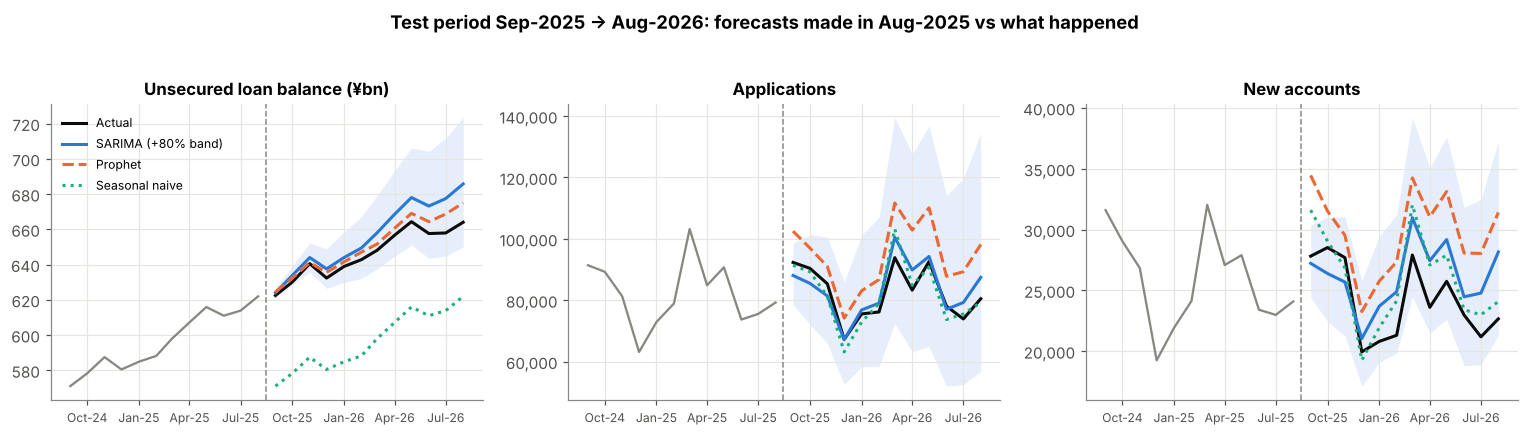

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (t, label) in zip(axes, TARGETS.items()):
    f = test_forecasts[t]
    scale = 1000 if t == "unsecured_loans_jpy_mn" else 1          # balance in ¥bn
    hist = y_all[t]["2024-09":"2025-08"] / scale
    ax.plot(hist.index, hist, color=GREY, lw=1.5)
    ax.fill_between(f["actual"].index, f["lo80"] / scale, f["hi80"] / scale, color=BLUE, alpha=0.12, lw=0)
    ax.plot(f["actual"].index, f["actual"] / scale, color="#0b0b0b", lw=2, label="Actual")
    ax.plot(f["SARIMA"].index, f["SARIMA"] / scale, color=BLUE, label="SARIMA (+80% band)")
    ax.plot(f["Prophet"].index, f["Prophet"] / scale, color=ORANGE, ls="--", label="Prophet")
    ax.plot(f["Seasonal naive"].index, f["Seasonal naive"] / scale, color=AQUA, ls=":", label="Seasonal naive")
    ax.set_title(label.replace("(¥mn)", "(¥bn)"), fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.axvline(pd.Timestamp("2025-08-15"), color=GREY, lw=1, ls="--")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
    ax.tick_params(axis="x", labelsize=8)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Test period Sep-2025 → Aug-2026: forecasts made in Aug-2025 vs what happened", fontweight="bold", y=1.03)
fig.tight_layout(); save(fig, "07_test_period_forecasts.png"); plt.show()

### 3.4 Which model is better, and why

**SARIMA is the most reliable model for all three targets.** It has the lowest average MAPE and RMSE across the 9-origin backtest:

- **Loan balance:** ~1.2% average error, 12 months ahead. The balance is a slow-moving *stock* (this month = last month + new lending − repayments), so it is very predictable. Prophet is close; seasonal naive is ~8% off because it ignores growth.
- **Applications and new accounts:** much harder (~16–18% backtest error). These are *flows* driven by marketing and credit policy, and they went through two regime changes (the post-COVID surge, then the 2024–25 contract-rate slide). The worst errors come from the 2023 origins, which were forecasting just as the surge ended.

**Be honest about the test year.** On the single Sep-25 → Aug-26 test window, seasonal naive beats SARIMA for applications and new accounts, and Prophet edges SARIMA on the balance. The reason: that year was unusually *flat*, and when nothing changes, "same as last year" is hard to beat. Across 9 origins, which include years when things *did* change, SARIMA wins. We choose the model that is robust across many periods, not the winner of one lucky year.

**Why Prophet underperforms here.** Its piecewise-linear trend keeps extrapolating the last slope it saw. For new accounts it carried the 2022–23 surge forward and **over-forecast by ~24%** in the test year. With only ~170 monthly points and several regime shifts, SARIMA's "learn from recent changes" approach adapts faster.

**Is SARIMA well calibrated?** In the backtest, its 80% intervals contained the actual value ~73–91% of the time, close to the promised 80%. So the bands can be used for planning ranges.

**Known weaknesses:**
- SARIMA **over-forecast new accounts by ~9%** in the test year, because it doesn't know the contract rate is falling. Treat its new-account forecast as an upper-middle case.
- For the balance model, the residual Ljung-Box test (below) flags some leftover autocorrelation at lag 24. That's minor for a 12-month horizon, but worth saying in an interview.

In [16]:
print("Ljung-Box test on SARIMA residuals (fitted on all data). p > 0.05 = no leftover pattern")
for t in TARGETS:
    _, model = forecast_sarima(y_all[t], t)
    lb = acorr_ljungbox(model.resid[13:], lags=[12, 24], return_df=True)    # skip the first 13 start-up residuals
    print(f"  {TARGETS[t]:32s} lag-12 p = {lb.lb_pvalue.iloc[0]:.3f}   lag-24 p = {lb.lb_pvalue.iloc[1]:.3f}")

Ljung-Box test on SARIMA residuals (fitted on all data). p > 0.05 = no leftover pattern


  Unsecured loan balance (¥mn)     lag-12 p = 0.109   lag-24 p = 0.009


  Applications                     lag-12 p = 0.200   lag-24 p = 0.094


  New accounts                     lag-12 p = 0.980   lag-24 p = 0.935


### 3.5 Final 12-month forecast (Sep-2026 → Aug-2027)

Refit SARIMA on **all** data up to Aug-2026 (same orders), forecast 12 months, and show Prophet as a second opinion.

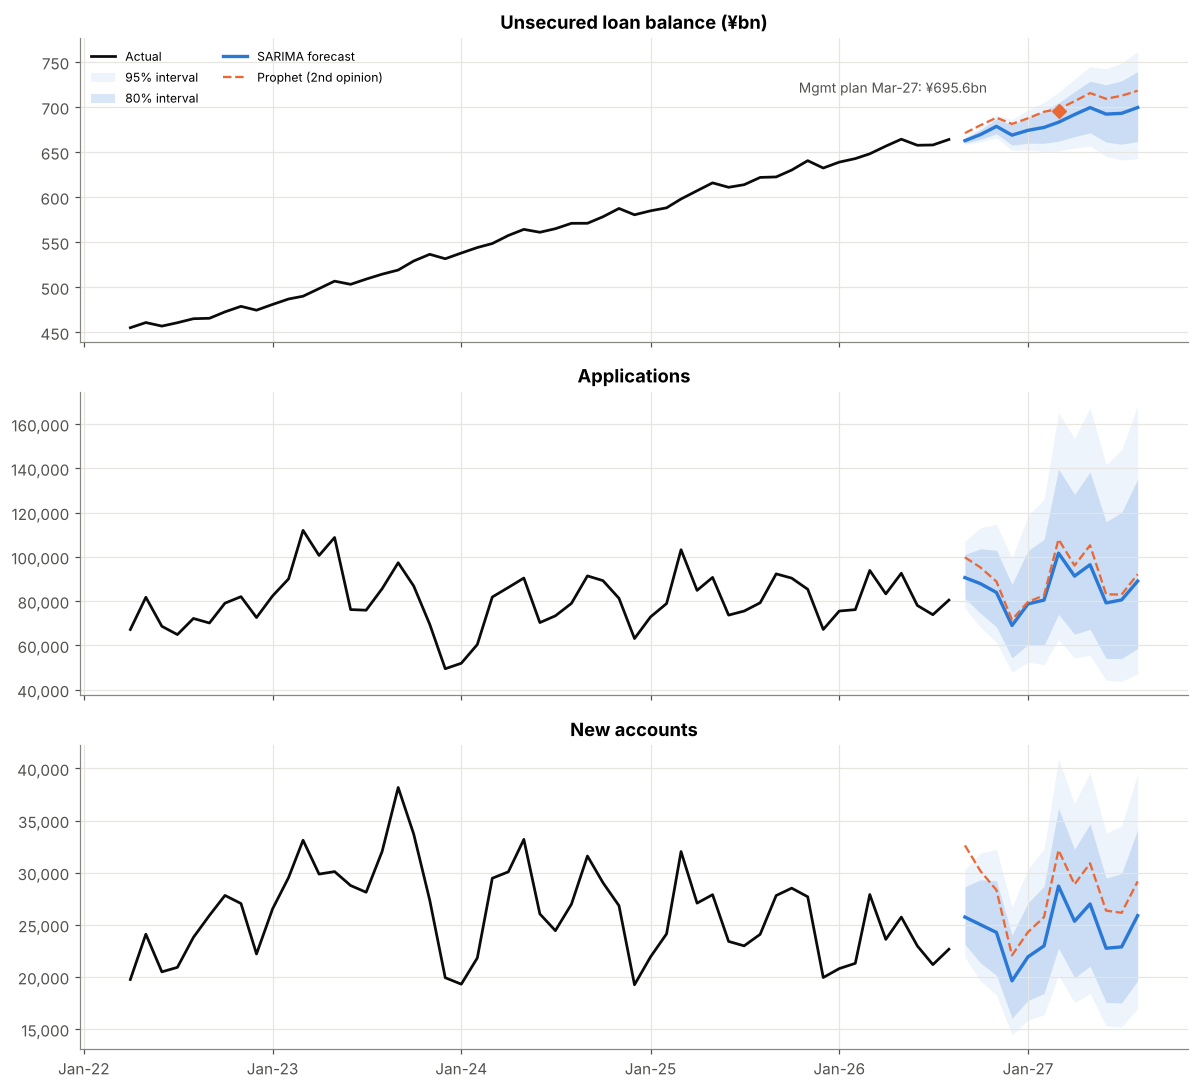

In [17]:
final, prophet_final = {}, {}
for t in TARGETS:
    final[t], _ = forecast_sarima(y_all[t], t)
    prophet_final[t] = forecast_prophet(y_all[t])

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, (t, label) in zip(axes, TARGETS.items()):
    scale = 1000 if t == "unsecured_loans_jpy_mn" else 1
    hist = y_all[t]["2022-04":] / scale
    f = final[t] / scale
    ax.plot(hist.index, hist, color="#0b0b0b", lw=1.8, label="Actual")
    ax.fill_between(f.index, f["lo95"], f["hi95"], color=BLUE, alpha=0.08, lw=0, label="95% interval")
    ax.fill_between(f.index, f["lo80"], f["hi80"], color=BLUE, alpha=0.18, lw=0, label="80% interval")
    ax.plot(f.index, f["forecast"], color=BLUE, lw=2.2, label="SARIMA forecast")
    ax.plot(prophet_final[t].index, prophet_final[t] / scale, color=ORANGE, ls="--", lw=1.5, label="Prophet (2nd opinion)")
    ax.set_title(label.replace("(¥mn)", "(¥bn)"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
axes[0].scatter([pd.Timestamp("2027-03-01")], [695.6], marker="D", color=ORANGE, zorder=5, s=40)
axes[0].annotate("Mgmt plan Mar-27: ¥695.6bn", (pd.Timestamp("2027-03-01"), 695.6), xytext=(-170, 12),
                 textcoords="offset points", fontsize=9, color="#52514e")
axes[0].legend(frameon=False, fontsize=8, loc="upper left", ncol=2)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
fig.tight_layout(); save(fig, "08_final_forecast.png"); plt.show()

In [18]:
fc_table = pd.DataFrame({
    "Balance ¥bn": final["unsecured_loans_jpy_mn"]["forecast"] / 1000,
    "Balance 80% low": final["unsecured_loans_jpy_mn"]["lo80"] / 1000,
    "Balance 80% high": final["unsecured_loans_jpy_mn"]["hi80"] / 1000,
    "Applications": final["applications"]["forecast"],
    "New accounts": final["new_accounts"]["forecast"],
    "New acc. 80% low": final["new_accounts"]["lo80"],
    "New acc. 80% high": final["new_accounts"]["hi80"],
})
fc_table["Implied contract rate %"] = fc_table["New accounts"] / fc_table["Applications"] * 100
fc_table.index = fc_table.index.strftime("%b-%Y")
fc_table.round(1).to_csv(ROOT / "data" / "processed" / "forecast_12m.csv")
fmt = {c: "{:,.0f}" for c in fc_table.columns}
fmt.update({"Balance ¥bn": "{:,.1f}", "Balance 80% low": "{:,.1f}", "Balance 80% high": "{:,.1f}", "Implied contract rate %": "{:.1f}"})
fc_table.style.format(fmt)

,Balance ¥bn,Balance 80% low,Balance 80% high,Applications,New accounts,New acc. 80% low,New acc. 80% high,Implied contract rate %
Sep-2026,662.7,659.9,665.5,"90,622","25,742","23,135","28,644",28.4
Oct-2026,669.4,664.2,674.7,"87,907","25,017","21,348","29,316",28.5
Nov-2026,678.5,670.3,686.9,"83,918","24,267","20,155","29,218",28.9
Dec-2026,668.8,657.7,680.1,"69,027","19,623","16,049","23,993",28.4
Jan-2027,674.2,659.8,688.8,"78,760","21,930","17,739","27,111",27.8
Feb-2027,677.4,659.8,695.5,"80,491","22,980","18,408","28,687",28.5
Mar-2027,683.1,662.1,704.8,"101,686","28,713","22,782","36,186",28.2
Apr-2027,691.7,667.1,717.1,"91,323","25,345","19,920","32,246",27.8
May-2027,699.4,671.3,728.7,"96,449","26,998","21,023","34,670",28.0
Jun-2027,692.2,661.1,724.7,"79,216","22,752","17,558","29,483",28.7


### 3.6 Forecast vs management's own plan (FY ending Mar-2027)

AIFUL publishes a full-year plan in its quarterly Data Book (Q1 FY2027/3, sheet "11 AIFUL Operating Results"): **unsecured balance ¥695.6bn** and **295,000 new unsecured customers**. Our FY figure = actual Apr–Aug 2026 + forecast Sep-2026–Mar-2027.

In [19]:
fy_months = pd.date_range("2026-04-01", "2027-03-01", freq="MS")
def fy_total(t):
    combined = pd.concat([y_all[t]["2026-04":"2026-08"], final[t]["forecast"]])
    return combined[fy_months].sum()

bal_mar27 = final["unsecured_loans_jpy_mn"].loc["2027-03-01"]
plan = pd.DataFrame({
    "Management plan": [695_600, 295_000, np.nan],
    "Our forecast": [bal_mar27["forecast"], fy_total("new_accounts"), fy_total("applications")],
    "80% range": [f"{bal_mar27['lo80']:,.0f} – {bal_mar27['hi80']:,.0f}", "", ""],
    "FY2025 actual": [y_all["unsecured_loans_jpy_mn"]["2026-03-01"], y_all["new_accounts"]["2025-04":"2026-03"].sum(),
                      y_all["applications"]["2025-04":"2026-03"].sum()],
}, index=["Unsecured balance at Mar-2027 (¥mn)", "New accounts FY2026 (Apr-26–Mar-27)", "Applications FY2026"])
plan["Forecast vs plan %"] = (plan["Our forecast"] / plan["Management plan"] - 1) * 100
plan["Forecast vs FY2025 %"] = (plan["Our forecast"] / plan["FY2025 actual"] - 1) * 100
plan.style.format({"Management plan": "{:,.0f}", "Our forecast": "{:,.0f}", "FY2025 actual": "{:,.0f}",
                   "Forecast vs plan %": "{:+.1f}", "Forecast vs FY2025 %": "{:+.1f}"}, na_rep="—")

,Management plan,Our forecast,80% range,FY2025 actual,Forecast vs plan %,Forecast vs FY2025 %
Unsecured balance at Mar-2027 (¥mn),"695,600","683,119","662,123 – 704,781","648,117",-1.8,+5.4
New accounts FY2026 (Apr-26–Mar-27),"295,000","284,426",,"299,410",-3.6,-5.0
Applications FY2026,—,"1,000,710",,"984,922",—,+1.6


**What the forecast says**
1. **Demand holds up.** Applications are forecast at ~1.0 million in FY2026, flat to slightly up on FY2025.
2. **Conversion keeps sliding.** New accounts ~284k (−5% YoY, ~4% **below** the 295k plan). The implied contract rate stays ~28%.
3. **Loan growth slows.** Balance ~¥683bn at Mar-2027, about ¥12bn (~2%) **below plan**. The plan sits near the top of the 80% interval: reachable, but only if conversion improves. YoY growth falls from 6.8% today to ~5% by Aug-2027.
4. Since SARIMA over-forecast new accounts in the test year, the risk to these numbers is **to the downside** unless the contract rate recovers.

Source for plan figures: [Muninova Data Book Q1 FY2027/3 (xlsx)](https://www.muninova.co.jp/ir/xlsx/DB202606.xlsx).

## 4. Management summary

The one-page report for management is in [`reports/management_report.md`](../reports/management_report.md) (PDF version alongside it). The cell below builds its headline chart and checks the key numbers quoted in the report.

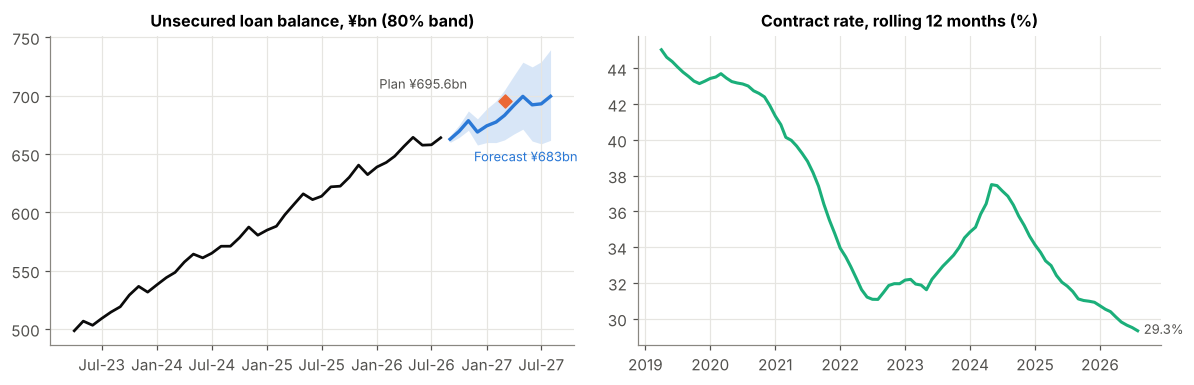

Balance Aug-26: ¥664.0bn, YoY 6.8%
Forecast Aug-27: ¥699.5bn -> YoY 5.3%
New-account gap to plan: 10,574
Forecast applications Sep-26–Mar-27: 592,410; +2pp contract rate on these = 11,848 extra accounts


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

# Left: loan balance - actual, SARIMA forecast with 80% band, management plan
hist = y_all["unsecured_loans_jpy_mn"]["2023-04":] / 1000
f = final["unsecured_loans_jpy_mn"] / 1000
ax1.plot(hist.index, hist, color="#0b0b0b", lw=1.8)
ax1.fill_between(f.index, f["lo80"], f["hi80"], color=BLUE, alpha=0.18, lw=0)
ax1.plot(f.index, f["forecast"], color=BLUE, lw=2.2)
ax1.scatter([pd.Timestamp("2027-03-01")], [695.6], marker="D", color=ORANGE, zorder=5, s=36)
ax1.annotate("Plan ¥695.6bn", (pd.Timestamp("2027-03-01"), 695.6), xytext=(-82, 8), textcoords="offset points", fontsize=8.5, color="#52514e")
ax1.annotate(f"Forecast ¥{f.loc['2027-03-01','forecast']:.0f}bn", (pd.Timestamp("2027-03-01"), f.loc["2027-03-01", "forecast"]),
             xytext=(-20, -30), textcoords="offset points", fontsize=8.5, color=BLUE)
ax1.set_title("Unsecured loan balance, ¥bn (80% band)", fontsize=10.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))

# Right: contract rate - the driver
cr = (df["new_accounts"].astype(float).rolling(12).sum() / df["applications"].astype(float).rolling(12).sum() * 100)["2019-04":]
ax2.plot(cr.index, cr, color=AQUA, lw=2)
ax2.annotate(f"{cr.iloc[-1]:.1f}%", (cr.index[-1], cr.iloc[-1]), xytext=(4, -2), textcoords="offset points", fontsize=8.5, color="#52514e")
ax2.set_title("Contract rate, rolling 12 months (%)", fontsize=10.5)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout(); save(fig, "09_report_summary.png"); plt.show()

# Numbers quoted in the management report - printed here so every figure is traceable to code
gap_accounts = plan.loc["New accounts FY2026 (Apr-26–Mar-27)", "Management plan"] - plan.loc["New accounts FY2026 (Apr-26–Mar-27)", "Our forecast"]
remaining_apps = final["applications"]["forecast"]["2026-09":"2027-03"].sum()
print(f"Balance Aug-26: ¥{y_all['unsecured_loans_jpy_mn'].iloc[-1]/1000:.1f}bn, YoY {yoy.iloc[-1]:.1f}%")
print(f"Forecast Aug-27: ¥{f['forecast'].iloc[-1]:.1f}bn -> YoY {(final['unsecured_loans_jpy_mn']['forecast'].iloc[-1]/y_all['unsecured_loans_jpy_mn'].iloc[-1]-1)*100:.1f}%")
print(f"New-account gap to plan: {gap_accounts:,.0f}")
print(f"Forecast applications Sep-26–Mar-27: {remaining_apps:,.0f}; +2pp contract rate on these = {remaining_apps*0.02:,.0f} extra accounts")